<a href="https://colab.research.google.com/github/Cheetah-lhp/MachineLearning/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
from tensorflow.keras.datasets import mnist

In [44]:
data = mnist.load_data()

In [45]:
x_train, y_train = data[0]
x_test, y_test = data[1]

In [46]:
print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [47]:
x_train = x_train.reshape(-1, 28*28) / 255.0
x_test = x_test.reshape(-1, 28*28) / 255.0

In [48]:
def one_hot(y):
  y_onehot = np.zeros((len(y), 10))
  for i in range(len(y)):
    y_onehot[i, y[i]] = 1
  return y_onehot

In [49]:
y_train = one_hot(y_train)
y_test = one_hot(y_test)

In [50]:
print(y_train[0:10])

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [51]:
input_size = 784
hidden_size = 30
output_size = 10

w1 = np.random.randn(hidden_size, input_size)
b1 = np.zeros((hidden_size,1))

w2 = np.random.randn(output_size, hidden_size)
b2 = np.zeros((output_size,1))

lr = 0.5
epochs = 5

In [52]:
def sigmoid(z):
  return 1 / (1+np.exp(-z))

In [53]:
loss_train = []
for epoch in range(epochs):
  for i in range(len(x_train)):
    loss = 0
    x = x_train[i].reshape(784,1)
    y = y_train[i].reshape(10,1)

    z1 = np.dot(w1, x) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(w2, a1) + b2
    a2 = sigmoid(z2)

    delta2 = (a2 - y) * a2 * (1 - a2)
    dw2 = np.dot(delta2, a1.T)
    db2 = delta2

    delta1 = np.dot(w2.T, delta2) * a1 * (1 - a1)
    dw1 = np.dot(delta1, x.T)
    db1 = delta1

    w1 -= lr * dw1
    b1 -= lr * db1
    w2 -= lr * dw2
    b2 -= lr * db2
    loss += np.mean(np.square(a2 - y)) #MSE
  loss_train.append(loss)
  print(f"Epoch: {epoch+1} Loss: {loss}")

Epoch: 1 Loss: 0.0003917848180617957
Epoch: 2 Loss: 0.0008483919853119007
Epoch: 3 Loss: 0.0007171873676701007
Epoch: 4 Loss: 4.895067249671844e-05
Epoch: 5 Loss: 0.0006893289035702361


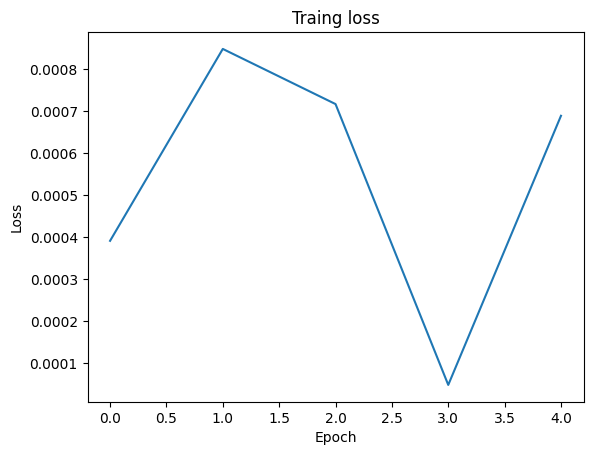

In [54]:
import matplotlib.pyplot as plt
plt.plot(loss_train)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Traing loss")
plt.show()

In [55]:
def predict(x):
  x = x.reshape(784,1)

  z1 = np.dot(w1, x) + b1
  a1 = sigmoid(z1)

  z2 = np.dot(w2, a1) + b2
  a2 = sigmoid(z2)

  pred = np.argmax(a2)

  return pred

In [56]:
correct = 0

for i in range(len(x_test)):
  if predict(x_test[i]) == np.argmax(y_test[i]):
    correct += 1
print("Acc: ", correct / len(x_test))

Acc:  0.9336


Vẽ không gian tham số và đường biên giới phân lớp trên mặt phẳng 2D sử dụng T-SNE

In [57]:
from sklearn.manifold import TSNE
#mnist 60000 sampel, tsne chay phep toan giam chieu rat lau, nen lay subset nho lam vi du
subset = 3000

tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_data = tsne.fit_transform(x_train[:subset])

In [58]:
print(tsne_data.shape)

(3000, 2)


In [59]:
labels = np.argmax(y_train, axis=1)
#chuyen lai y_train tu onehot thanh nhan 0-9

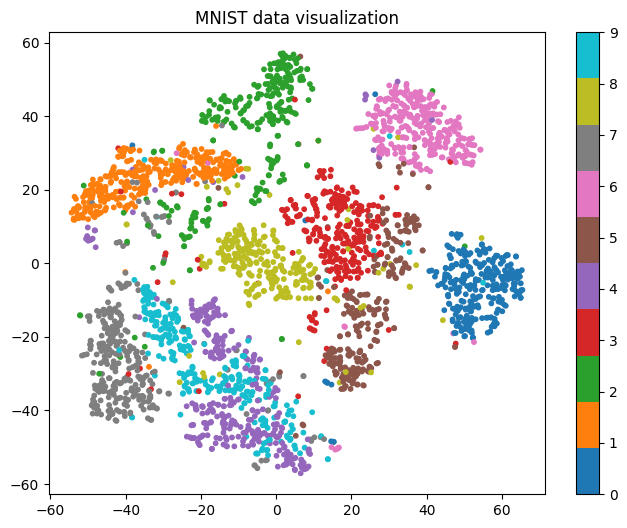

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    tsne_data[:,0],
    tsne_data[:,1],
    c=labels[:subset],
    cmap='tab10',
    s=10
)
plt.colorbar()
plt.title("MNIST data visualization")
plt.show()

In [61]:
x_min, x_max = tsne_data[:,0].min()-5, tsne_data[:,0].max()+5
y_min, y_max = tsne_data[:,1].min()-5, tsne_data[:,1].max()+5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

In [62]:
from sklearn.neighbors import KNeighborsRegressor
#vi tsne khong co inverse chieu (nhu PCA), dung knn approximation de chuyen grid tro ve 784 chieu
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(tsne_data, x_train[:subset])

grid = np.c_[xx.ravel(), yy.ravel()]

grid_highD = knn.predict(grid)

In [66]:
print(grid.shape)
print(grid_highD.shape)

(40000, 2)
(40000, 784)


Predict toàn grid tìm đường phân lớp

In [63]:
Z = np.array([predict(p) for p in grid_highD])
Z = Z.reshape(xx.shape)

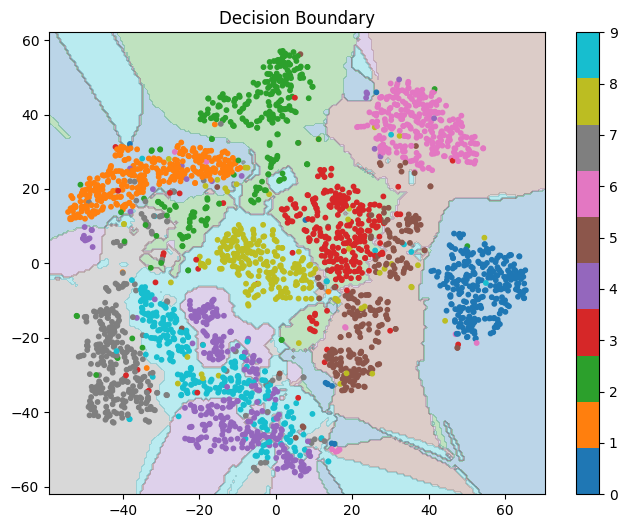

In [68]:
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='tab10')

plt.scatter(
    tsne_data[:,0],
    tsne_data[:,1],
    c=labels[:subset],
    cmap='tab10',
    s=10
)
plt.colorbar()
plt.title("Decision Boundary")
plt.show()